# 05 — PlantVillage Classification Robustness and Model Comparison

Final comparison of:

1. Standard RGB EfficientNet-B0
2. Leaf-Only Teacher EfficientNet-B0
3. Proposed MG-CCD EfficientNet-B0

## Important interpretation

The teacher is a **privileged-information model** trained on leaf-only images.  
The two deployment-style RGB models are:

- Standard RGB baseline
- MG-CCD student

The proposed model is not expected to necessarily beat the baseline on ordinary PlantVillage RGB accuracy. Its main research question is:

> Can we preserve near-perfect ordinary RGB classification while dramatically improving robustness when the background changes?

## No GPU required

Collect the lightweight result folders into one Drive:

```text
MyDrive/PlantVillage_Classification/
└── experiments/
    ├── Standard_RGB_EfficientNetB0/
    │   └── results/
    ├── Leaf_Only_Teacher_EfficientNetB0/
    │   └── results/
    └── MG_CCD_EfficientNetB0/
        └── results/
```


# STEP 1 — Imports

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# STEP 2 — Mount Drive and Define Paths

In [2]:
from google.colab import drive

drive.mount("/content/drive")

PROJECT_DIR = Path(
    "/content/drive/MyDrive/PlantVillage_Classification"
)

EXPERIMENTS_DIR = PROJECT_DIR/"experiments"

COMPARISON_DIR = EXPERIMENTS_DIR/"Model_Comparison"

COMPARISON_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_DIRS = {
    "Standard RGB":
        EXPERIMENTS_DIR/
        "Standard_RGB_EfficientNetB0",

    "Leaf-Only Teacher":
        EXPERIMENTS_DIR/
        "Leaf_Only_Teacher_EfficientNetB0",

    "MG-CCD":
        EXPERIMENTS_DIR/
        "MG_CCD_EfficientNetB0",
}

print("Comparison output:", COMPARISON_DIR)


Mounted at /content/drive
Comparison output: /content/drive/MyDrive/PlantVillage_Classification/experiments/Model_Comparison


# STEP 3 — Verify Required Result Files

In [3]:
required = {}

for model_name, model_dir in MODEL_DIRS.items():

    required[model_name] = {
        "metrics":
            model_dir/
            "results"/
            "multiview_test_metrics.json",

        "summary":
            model_dir/
            "results"/
            "experiment_summary.json",

        "history":
            model_dir/
            "results"/
            "training_history.csv",
    }

for model_name, paths in required.items():

    print("\n", model_name)

    for key,path in paths.items():

        exists = path.exists()

        print(
            "✅" if exists else "❌",
            key,
            path
        )

        assert exists, (
            f"Missing {key} for {model_name}: {path}"
        )

print("\n✅ All three completed experiments found.")



 Standard RGB
✅ metrics /content/drive/MyDrive/PlantVillage_Classification/experiments/Standard_RGB_EfficientNetB0/results/multiview_test_metrics.json
✅ summary /content/drive/MyDrive/PlantVillage_Classification/experiments/Standard_RGB_EfficientNetB0/results/experiment_summary.json
✅ history /content/drive/MyDrive/PlantVillage_Classification/experiments/Standard_RGB_EfficientNetB0/results/training_history.csv

 Leaf-Only Teacher
✅ metrics /content/drive/MyDrive/PlantVillage_Classification/experiments/Leaf_Only_Teacher_EfficientNetB0/results/multiview_test_metrics.json
✅ summary /content/drive/MyDrive/PlantVillage_Classification/experiments/Leaf_Only_Teacher_EfficientNetB0/results/experiment_summary.json
✅ history /content/drive/MyDrive/PlantVillage_Classification/experiments/Leaf_Only_Teacher_EfficientNetB0/results/training_history.csv

 MG-CCD
✅ metrics /content/drive/MyDrive/PlantVillage_Classification/experiments/MG_CCD_EfficientNetB0/results/multiview_test_metrics.json
✅ summary 

# STEP 4 — Load Results

In [4]:
metrics = {}
summaries = {}
histories = {}

for model_name, paths in required.items():

    with open(
        paths["metrics"],
        "r"
    ) as f:
        metrics[model_name] = json.load(f)

    with open(
        paths["summary"],
        "r"
    ) as f:
        summaries[model_name] = json.load(f)

    histories[model_name] = pd.read_csv(
        paths["history"]
    )

print("✅ Results loaded.")


✅ Results loaded.


# STEP 5 — Build Four-View Macro-F1 Comparison

In [5]:
views = [
    "original",
    "leaf_only",
    "background_only",
    "counterfactual"
]

rows = []

for model_name in [
    "Standard RGB",
    "Leaf-Only Teacher",
    "MG-CCD"
]:

    for view in views:

        result = metrics[
            model_name
        ][
            view
        ]

        rows.append({
            "Model":
                model_name,

            "View":
                view,

            "Accuracy":
                float(
                    result[
                        "accuracy"
                    ]
                ),

            "Balanced Accuracy":
                float(
                    result[
                        "balanced_accuracy"
                    ]
                ),

            "Macro Precision":
                float(
                    result[
                        "macro_precision"
                    ]
                ),

            "Macro Recall":
                float(
                    result[
                        "macro_recall"
                    ]
                ),

            "Macro F1":
                float(
                    result[
                        "macro_f1"
                    ]
                ),

            "Weighted F1":
                float(
                    result[
                        "weighted_f1"
                    ]
                ),
        })


comparison_long = pd.DataFrame(
    rows
)

display(
    comparison_long.style.format({
        "Accuracy":
            "{:.6f}",

        "Balanced Accuracy":
            "{:.6f}",

        "Macro Precision":
            "{:.6f}",

        "Macro Recall":
            "{:.6f}",

        "Macro F1":
            "{:.6f}",

        "Weighted F1":
            "{:.6f}",
    })
)


,Model,View,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Standard RGB,original,0.998527,0.997303,0.997985,0.997303,0.997589,0.998520
1,Standard RGB,leaf_only,0.648499,0.679518,0.785517,0.679518,0.648865,0.620375
2,Standard RGB,background_only,0.041429,0.060467,0.187151,0.060467,0.040040,0.029769
3,Standard RGB,counterfactual,0.873504,0.868014,0.898675,0.868014,0.868435,0.876070
4,Leaf-Only Teacher,original,0.954336,0.961644,0.951621,0.961644,0.950641,0.957100
5,Leaf-Only Teacher,leaf_only,0.997422,0.996246,0.996731,0.996246,0.996449,0.997415
6,Leaf-Only Teacher,background_only,0.135150,0.095278,0.243062,0.095278,0.080980,0.128564
7,Leaf-Only Teacher,counterfactual,0.967593,0.968580,0.952278,0.968580,0.957307,0.968056
8,MG-CCD,original,0.997790,0.997016,0.996892,0.997016,0.996907,0.997790
9,MG-CCD,leaf_only,0.989689,0.989382,0.985173,0.989382,0.986897,0.989770


# STEP 6 — Main Deployment Comparison: Standard RGB vs MG-CCD

In [6]:
deployment_models = [
    "Standard RGB",
    "MG-CCD"
]

deployment_rows = []

for model_name in deployment_models:

    original = metrics[
        model_name
    ][
        "original"
    ]

    cf = metrics[
        model_name
    ][
        "counterfactual"
    ]

    leaf = metrics[
        model_name
    ][
        "leaf_only"
    ]

    background = metrics[
        model_name
    ][
        "background_only"
    ]

    f1_drop = (
        original[
            "macro_f1"
        ]
        -
        cf[
            "macro_f1"
        ]
    )

    retention = (
        cf[
            "macro_f1"
        ]
        /
        original[
            "macro_f1"
        ]
    )

    deployment_rows.append({
        "Model":
            model_name,

        "Original Accuracy":
            original[
                "accuracy"
            ],

        "Original Macro F1":
            original[
                "macro_f1"
            ],

        "Counterfactual Macro F1":
            cf[
                "macro_f1"
            ],

        "Original→CF F1 Drop":
            f1_drop,

        "CF F1 Retention":
            retention,

        "Leaf-only Macro F1":
            leaf[
                "macro_f1"
            ],

        "Background-only Macro F1":
            background[
                "macro_f1"
            ],
    })


deployment_df = pd.DataFrame(
    deployment_rows
)


display(
    deployment_df.style.format({
        "Original Accuracy":
            "{:.6f}",

        "Original Macro F1":
            "{:.6f}",

        "Counterfactual Macro F1":
            "{:.6f}",

        "Original→CF F1 Drop":
            "{:.6f}",

        "CF F1 Retention":
            "{:.4%}",

        "Leaf-only Macro F1":
            "{:.6f}",

        "Background-only Macro F1":
            "{:.6f}",
    })
)


,Model,Original Accuracy,Original Macro F1,Counterfactual Macro F1,Original→CF F1 Drop,CF F1 Retention,Leaf-only Macro F1,Background-only Macro F1
0,Standard RGB,0.998527,0.997589,0.868435,0.129153,87.0535%,0.648865,0.040040
1,MG-CCD,0.997790,0.996907,0.995904,0.001002,99.8994%,0.986897,0.088776


# STEP 7 — Quantify the Proposed-Method Trade-off and Gain

In [7]:
std_original_f1 = (
    metrics[
        "Standard RGB"
    ][
        "original"
    ][
        "macro_f1"
    ]
)

std_cf_f1 = (
    metrics[
        "Standard RGB"
    ][
        "counterfactual"
    ][
        "macro_f1"
    ]
)

std_leaf_f1 = (
    metrics[
        "Standard RGB"
    ][
        "leaf_only"
    ][
        "macro_f1"
    ]
)

mg_original_f1 = (
    metrics[
        "MG-CCD"
    ][
        "original"
    ][
        "macro_f1"
    ]
)

mg_cf_f1 = (
    metrics[
        "MG-CCD"
    ][
        "counterfactual"
    ][
        "macro_f1"
    ]
)

mg_leaf_f1 = (
    metrics[
        "MG-CCD"
    ][
        "leaf_only"
    ][
        "macro_f1"
    ]
)


analysis = {
    "ordinary_macro_f1_delta_mg_minus_standard":
        float(
            mg_original_f1
            -
            std_original_f1
        ),

    "counterfactual_macro_f1_gain_mg_over_standard":
        float(
            mg_cf_f1
            -
            std_cf_f1
        ),

    "leaf_only_macro_f1_gain_mg_over_standard":
        float(
            mg_leaf_f1
            -
            std_leaf_f1
        ),

    "standard_original_to_counterfactual_drop":
        float(
            std_original_f1
            -
            std_cf_f1
        ),

    "mg_original_to_counterfactual_drop":
        float(
            mg_original_f1
            -
            mg_cf_f1
        ),
}


for key,value in analysis.items():

    print(
        f"{key}: "
        f"{value:.6f} "
        f"({value*100:.3f} percentage points)"
    )


ordinary_macro_f1_delta_mg_minus_standard: -0.000682 (-0.068 percentage points)
counterfactual_macro_f1_gain_mg_over_standard: 0.127469 (12.747 percentage points)
leaf_only_macro_f1_gain_mg_over_standard: 0.338032 (33.803 percentage points)
standard_original_to_counterfactual_drop: 0.129153 (12.915 percentage points)
mg_original_to_counterfactual_drop: 0.001002 (0.100 percentage points)


# STEP 8 — Four-View Macro-F1 Plot

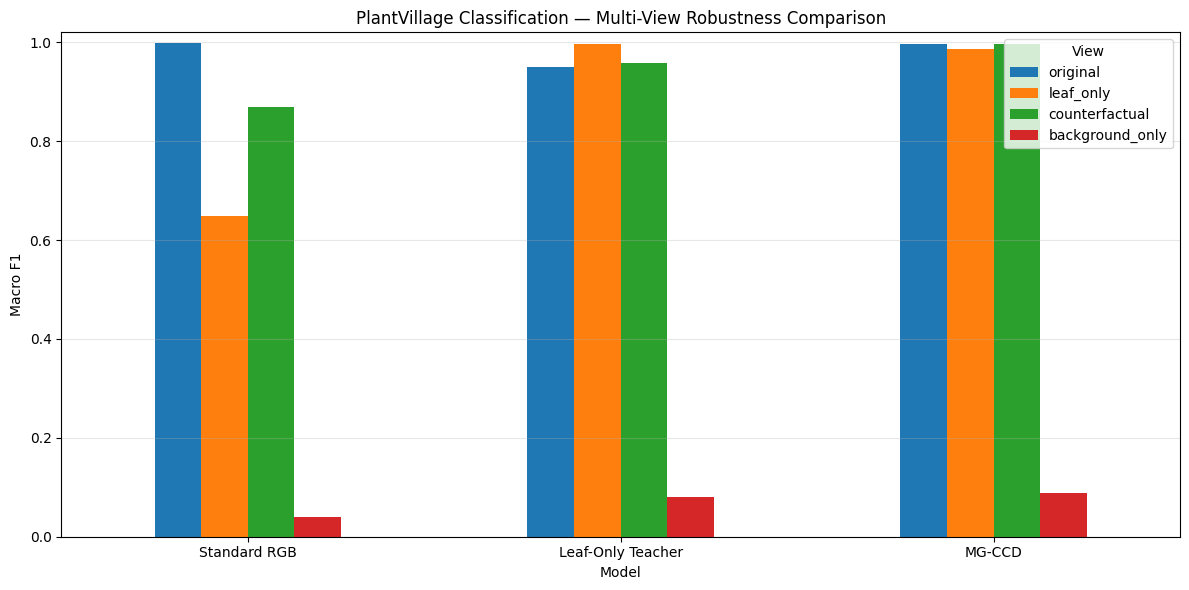

Saved: /content/drive/MyDrive/PlantVillage_Classification/experiments/Model_Comparison/multiview_macro_f1_comparison.png


In [8]:
plot_df = (
    comparison_long
    .pivot(
        index="Model",
        columns="View",
        values="Macro F1"
    )
    .loc[
        [
            "Standard RGB",
            "Leaf-Only Teacher",
            "MG-CCD"
        ]
    ]
)


ax = plot_df[
    [
        "original",
        "leaf_only",
        "counterfactual",
        "background_only"
    ]
].plot(
    kind="bar",
    figsize=(
        12,
        6
    )
)


ax.set_ylabel(
    "Macro F1"
)

ax.set_title(
    "PlantVillage Classification — Multi-View Robustness Comparison"
)

ax.set_ylim(
    0,
    1.02
)

ax.grid(
    axis="y",
    alpha=0.3
)

plt.xticks(
    rotation=0
)

plt.tight_layout()


MULTIVIEW_FIG = (
    COMPARISON_DIR/
    "multiview_macro_f1_comparison.png"
)


plt.savefig(
    MULTIVIEW_FIG,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "Saved:",
    MULTIVIEW_FIG
)


# STEP 9 — Original vs Counterfactual Macro-F1 Plot

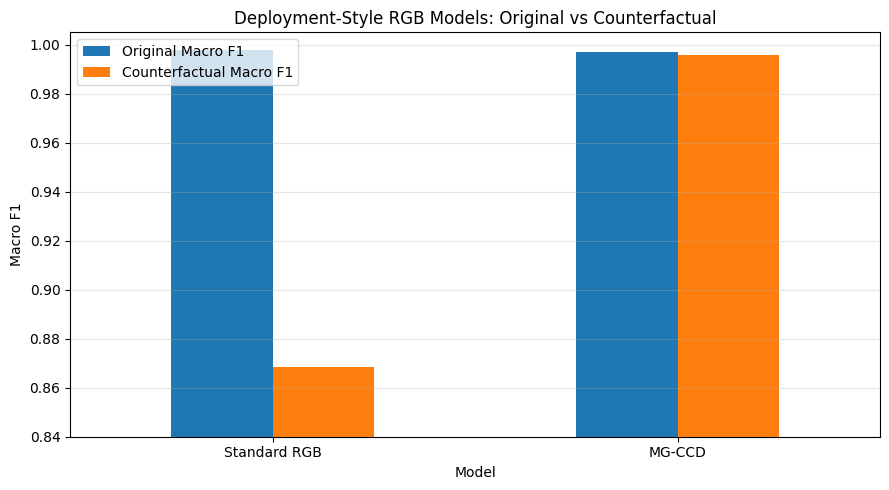

Saved: /content/drive/MyDrive/PlantVillage_Classification/experiments/Model_Comparison/original_vs_counterfactual_macro_f1.png


In [9]:
deploy_plot = (
    deployment_df
    .set_index(
        "Model"
    )
    [
        [
            "Original Macro F1",
            "Counterfactual Macro F1"
        ]
    ]
)


ax = deploy_plot.plot(
    kind="bar",
    figsize=(
        9,
        5
    )
)


ax.set_ylabel(
    "Macro F1"
)

ax.set_title(
    "Deployment-Style RGB Models: Original vs Counterfactual"
)

ax.set_ylim(
    0.84,
    1.005
)

ax.grid(
    axis="y",
    alpha=0.3
)

plt.xticks(
    rotation=0
)

plt.tight_layout()


ROBUSTNESS_FIG = (
    COMPARISON_DIR/
    "original_vs_counterfactual_macro_f1.png"
)


plt.savefig(
    ROBUSTNESS_FIG,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "Saved:",
    ROBUSTNESS_FIG
)


# STEP 10 — Robustness Drop Plot

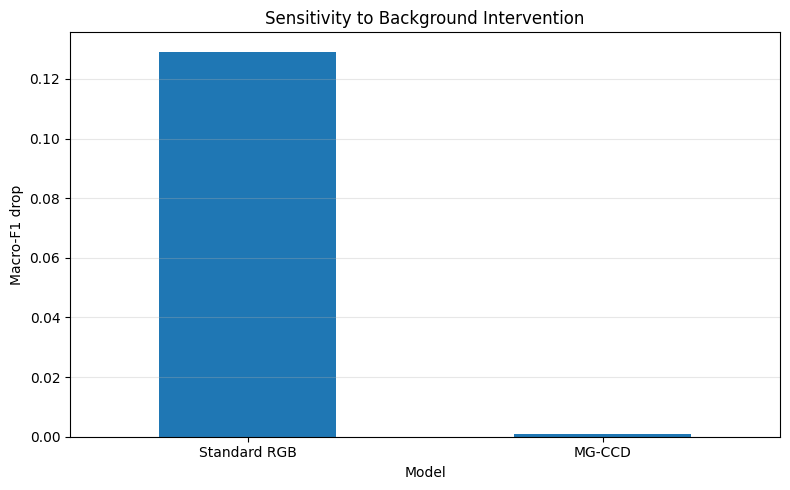

Saved: /content/drive/MyDrive/PlantVillage_Classification/experiments/Model_Comparison/counterfactual_macro_f1_drop.png


In [10]:
drop_df = (
    deployment_df[
        [
            "Model",
            "Original→CF F1 Drop"
        ]
    ]
    .set_index(
        "Model"
    )
)


ax = drop_df.plot(
    kind="bar",
    legend=False,
    figsize=(
        8,
        5
    )
)


ax.set_ylabel(
    "Macro-F1 drop"
)

ax.set_title(
    "Sensitivity to Background Intervention"
)

ax.grid(
    axis="y",
    alpha=0.3
)

plt.xticks(
    rotation=0
)

plt.tight_layout()


DROP_FIG = (
    COMPARISON_DIR/
    "counterfactual_macro_f1_drop.png"
)


plt.savefig(
    DROP_FIG,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "Saved:",
    DROP_FIG
)


# STEP 11 — Training-History Comparison

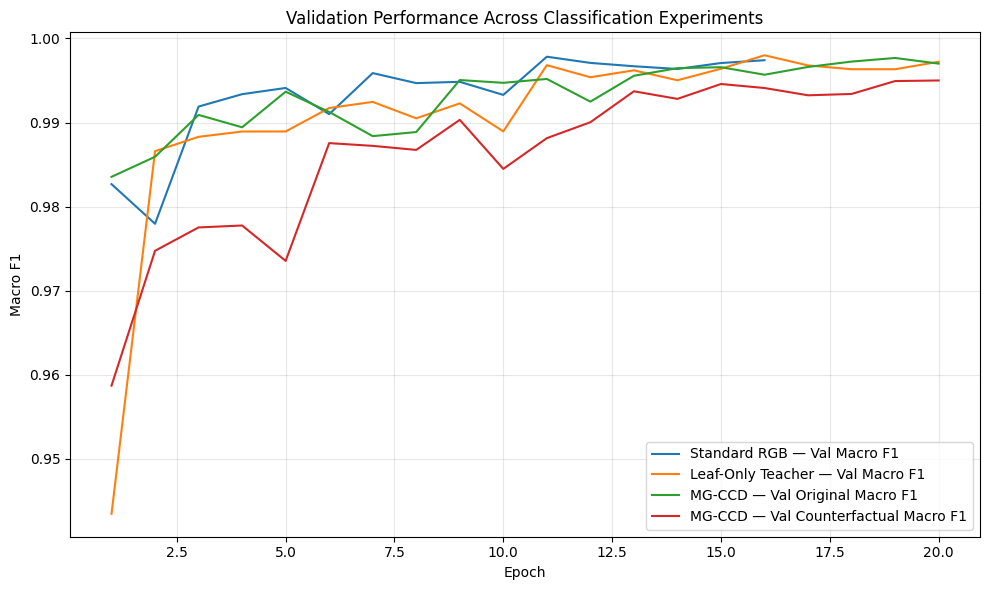

Saved: /content/drive/MyDrive/PlantVillage_Classification/experiments/Model_Comparison/classification_validation_history.png


In [11]:
plt.figure(
    figsize=(
        10,
        6
    )
)


standard_history = histories[
    "Standard RGB"
]

teacher_history = histories[
    "Leaf-Only Teacher"
]

mg_history = histories[
    "MG-CCD"
]


plt.plot(
    standard_history[
        "epoch"
    ],
    standard_history[
        "val_macro_f1"
    ],
    label=
        "Standard RGB — Val Macro F1"
)


plt.plot(
    teacher_history[
        "epoch"
    ],
    teacher_history[
        "val_macro_f1"
    ],
    label=
        "Leaf-Only Teacher — Val Macro F1"
)


plt.plot(
    mg_history[
        "epoch"
    ],
    mg_history[
        "val_original_macro_f1"
    ],
    label=
        "MG-CCD — Val Original Macro F1"
)


plt.plot(
    mg_history[
        "epoch"
    ],
    mg_history[
        "val_counterfactual_macro_f1"
    ],
    label=
        "MG-CCD — Val Counterfactual Macro F1"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Macro F1"
)

plt.title(
    "Validation Performance Across Classification Experiments"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()


TRAINING_FIG = (
    COMPARISON_DIR/
    "classification_validation_history.png"
)


plt.savefig(
    TRAINING_FIG,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "Saved:",
    TRAINING_FIG
)


# STEP 12 — Save Final Comparison Tables

In [12]:
COMPARISON_LONG_CSV = (
    COMPARISON_DIR/
    "classification_multiview_metrics.csv"
)

DEPLOYMENT_CSV = (
    COMPARISON_DIR/
    "deployment_model_comparison.csv"
)

ANALYSIS_JSON = (
    COMPARISON_DIR/
    "classification_robustness_analysis.json"
)


comparison_long.to_csv(
    COMPARISON_LONG_CSV,
    index=False
)


deployment_df.to_csv(
    DEPLOYMENT_CSV,
    index=False
)


with open(
    ANALYSIS_JSON,
    "w"
) as f:

    json.dump(
        analysis,
        f,
        indent=4
    )


print(
    "Saved:",
    COMPARISON_LONG_CSV
)

print(
    "Saved:",
    DEPLOYMENT_CSV
)

print(
    "Saved:",
    ANALYSIS_JSON
)


Saved: /content/drive/MyDrive/PlantVillage_Classification/experiments/Model_Comparison/classification_multiview_metrics.csv
Saved: /content/drive/MyDrive/PlantVillage_Classification/experiments/Model_Comparison/deployment_model_comparison.csv
Saved: /content/drive/MyDrive/PlantVillage_Classification/experiments/Model_Comparison/classification_robustness_analysis.json


# STEP 13 — Generate Paper-Ready LaTeX Table

In [13]:
latex_df = pd.DataFrame([
    {
        "Model":
            "Standard RGB",

        "Original Macro F1":
            metrics[
                "Standard RGB"
            ][
                "original"
            ][
                "macro_f1"
            ],

        "Leaf-only Macro F1":
            metrics[
                "Standard RGB"
            ][
                "leaf_only"
            ][
                "macro_f1"
            ],

        "Counterfactual Macro F1":
            metrics[
                "Standard RGB"
            ][
                "counterfactual"
            ][
                "macro_f1"
            ],

        "Background-only Macro F1":
            metrics[
                "Standard RGB"
            ][
                "background_only"
            ][
                "macro_f1"
            ],
    },

    {
        "Model":
            "Leaf-Only Teacher",

        "Original Macro F1":
            metrics[
                "Leaf-Only Teacher"
            ][
                "original"
            ][
                "macro_f1"
            ],

        "Leaf-only Macro F1":
            metrics[
                "Leaf-Only Teacher"
            ][
                "leaf_only"
            ][
                "macro_f1"
            ],

        "Counterfactual Macro F1":
            metrics[
                "Leaf-Only Teacher"
            ][
                "counterfactual"
            ][
                "macro_f1"
            ],

        "Background-only Macro F1":
            metrics[
                "Leaf-Only Teacher"
            ][
                "background_only"
            ][
                "macro_f1"
            ],
    },

    {
        "Model":
            "MG-CCD",

        "Original Macro F1":
            metrics[
                "MG-CCD"
            ][
                "original"
            ][
                "macro_f1"
            ],

        "Leaf-only Macro F1":
            metrics[
                "MG-CCD"
            ][
                "leaf_only"
            ][
                "macro_f1"
            ],

        "Counterfactual Macro F1":
            metrics[
                "MG-CCD"
            ][
                "counterfactual"
            ][
                "macro_f1"
            ],

        "Background-only Macro F1":
            metrics[
                "MG-CCD"
            ][
                "background_only"
            ][
                "macro_f1"
            ],
    },
])


latex_table = latex_df.to_latex(
    index=False,
    float_format=lambda x:
        f"{x:.6f}",
    caption=(
        "Multi-view classification performance "
        "on the fixed PlantVillage test set."
    ),
    label=
        "tab:classification_multiview"
)


LATEX_PATH = (
    COMPARISON_DIR/
    "classification_comparison_table.tex"
)


LATEX_PATH.write_text(
    latex_table,
    encoding="utf-8"
)


print(
    latex_table
)

print(
    "\\nSaved:",
    LATEX_PATH
)


\begin{table}
\caption{Multi-view classification performance on the fixed PlantVillage test set.}
\label{tab:classification_multiview}
\begin{tabular}{lrrrr}
\toprule
Model & Original Macro F1 & Leaf-only Macro F1 & Counterfactual Macro F1 & Background-only Macro F1 \\
\midrule
Standard RGB & 0.997589 & 0.648865 & 0.868435 & 0.040040 \\
Leaf-Only Teacher & 0.950641 & 0.996449 & 0.957307 & 0.080980 \\
MG-CCD & 0.996907 & 0.986897 & 0.995904 & 0.088776 \\
\bottomrule
\end{tabular}
\end{table}

\nSaved: /content/drive/MyDrive/PlantVillage_Classification/experiments/Model_Comparison/classification_comparison_table.tex


# STEP 14 — Print Final Interpretation

In [14]:
std_drop = (
    analysis[
        "standard_original_to_counterfactual_drop"
    ]
)

mg_drop = (
    analysis[
        "mg_original_to_counterfactual_drop"
    ]
)

cf_gain = (
    analysis[
        "counterfactual_macro_f1_gain_mg_over_standard"
    ]
)

ordinary_delta = (
    analysis[
        "ordinary_macro_f1_delta_mg_minus_standard"
    ]
)


print(
    "=" * 76
)

print(
    "FINAL CLASSIFICATION INTERPRETATION"
)

print(
    "=" * 76
)

print(
    f"Standard RGB original Macro F1: "
    f"{metrics['Standard RGB']['original']['macro_f1']:.6f}"
)

print(
    f"MG-CCD original Macro F1: "
    f"{metrics['MG-CCD']['original']['macro_f1']:.6f}"
)

print(
    f"Ordinary Macro-F1 change (MG-CCD - baseline): "
    f"{ordinary_delta:.6f} "
    f"({ordinary_delta*100:.3f} percentage points)"
)

print()

print(
    f"Standard RGB counterfactual Macro F1: "
    f"{metrics['Standard RGB']['counterfactual']['macro_f1']:.6f}"
)

print(
    f"MG-CCD counterfactual Macro F1: "
    f"{metrics['MG-CCD']['counterfactual']['macro_f1']:.6f}"
)

print(
    f"Counterfactual Macro-F1 gain: "
    f"{cf_gain:.6f} "
    f"({cf_gain*100:.3f} percentage points)"
)

print()

print(
    f"Standard RGB original→counterfactual drop: "
    f"{std_drop:.6f} "
    f"({std_drop*100:.3f} percentage points)"
)

print(
    f"MG-CCD original→counterfactual drop: "
    f"{mg_drop:.6f} "
    f"({mg_drop*100:.3f} percentage points)"
)

print()

print(
    "Conclusion: MG-CCD preserves near-baseline ordinary RGB "
    "performance while strongly improving robustness to the "
    "controlled background intervention."
)

print()

print(
    "Caution: background-only performance should be treated as "
    "a diagnostic, not as a pure measure of background shortcut "
    "learning, because mask imperfections may leave residual "
    "leaf evidence."
)


FINAL CLASSIFICATION INTERPRETATION
Standard RGB original Macro F1: 0.997589
MG-CCD original Macro F1: 0.996907
Ordinary Macro-F1 change (MG-CCD - baseline): -0.000682 (-0.068 percentage points)

Standard RGB counterfactual Macro F1: 0.868435
MG-CCD counterfactual Macro F1: 0.995904
Counterfactual Macro-F1 gain: 0.127469 (12.747 percentage points)

Standard RGB original→counterfactual drop: 0.129153 (12.915 percentage points)
MG-CCD original→counterfactual drop: 0.001002 (0.100 percentage points)

Conclusion: MG-CCD preserves near-baseline ordinary RGB performance while strongly improving robustness to the controlled background intervention.

Caution: background-only performance should be treated as a diagnostic, not as a pure measure of background shortcut learning, because mask imperfections may leave residual leaf evidence.


# Final scientific interpretation

The strongest classification result is **not** that MG-CCD has the highest ordinary PlantVillage score.

The standard RGB model is marginally higher on ordinary RGB Macro F1.

The contribution is instead:

```text
Near-equivalent ordinary RGB classification
+
very large counterfactual robustness improvement
+
much stronger leaf-only performance
```

This supports the use of segmentation-derived privileged information and counterfactual background intervention as a robustness-oriented classification strategy.

The `background_only` diagnostic must be interpreted cautiously because predicted masks are not perfect, so residual leaf pixels can remain outside the masked region.
